# Simulating ZeRO-1 / ZeRO-2 / ZeRO-3 on 32 Virtual GPUs

This notebook builds a small neural network, splits its parameters, gradients
and optimizer state across 32 simulated devices in four different ways
(ordinary data parallelism, then ZeRO stages 1, 2 and 3), runs a real training
step under each one, and measures how much memory each device needs and how
many bytes travel over the "network" per step. The numbers come from actual
`numpy` array sizes rather than from plugging values into a formula.

A note on the 32 GPUs: this machine doesn't have 32 accelerators, and neither
does a typical Colab instance. So a `VirtualGPU` here is a Python object with
one rule enforced on it, that it may only touch its own shard of the model,
which is the same restriction a real GPU works under. The 32 ranks run
sequentially in one process. That captures ZeRO's memory layout and
communication pattern accurately, which is the thing the algorithm actually
changes, but it doesn't capture the wall-clock speedup you'd get from 32 real
GPUs computing in parallel. Compute time here is whatever one CPU core manages.

The code lives in three files:

```
src/zero_sim/model.py       TinyMLP: flat-buffer numpy MLP, forward + backward
src/zero_sim/optimizer.py   AdamShard: Adam over a flat buffer or a shard of one
src/zero_sim/cluster.py     VirtualGPU + ZeROCluster: the simulator itself
```

In [1]:
# On Colab: clone the repo first, install deps, then point sys.path at src/
#   !pip install -q numpy matplotlib pandas
#   import sys; sys.path.insert(0, "/content/zero-parallelism-sim/src")

import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from zero_sim import TinyMLP, ZeROCluster, shard_bounds

np.random.seed(0)
print("numpy:", np.__version__, "| pandas:", pd.__version__)

numpy: 2.4.4 | pandas: 3.0.2


## 1. The memory problem

In plain fp32 data parallelism with Adam, every GPU holds a complete copy of
four things:

| Buffer            | Bytes / parameter | Used by |
|--------------------|:---:|---|
| Parameters (P)      | 4  | forward pass |
| Gradients (G)        | 4  | backward pass |
| Adam momentum (m)    | 4  | optimizer step |
| Adam variance (v)    | 4  | optimizer step |
| **Total / GPU**       | **16** | |

Sixteen bytes per parameter, replicated on every single GPU. Once you have
more than one device most of that is waste. GPU 7 keeps its own copy of the
Adam state for parameter #12,345 even though the update for that parameter is
the same arithmetic no matter who performs it, and every other GPU is
computing it too.

ZeRO removes the duplication by partitioning each buffer across the `N`
data-parallel GPUs instead of replicating it, in three increasingly aggressive
stages:

* **ZeRO-1** (`P_os`) partitions the optimizer state (m, v).
  Memory per GPU works out to roughly `4 + 4 + 8/N` bytes per parameter.
* **ZeRO-2** (`P_os+g`) partitions the gradients as well.
  Roughly `4 + 12/N` bytes per parameter.
* **ZeRO-3** (`P_os+g+p`) partitions the parameters too.
  Roughly `16/N` bytes per parameter in steady state.

The easy thing to miss is that none of this reduces the amount of compute a
GPU does. Every GPU still runs a full forward and backward pass over its own
batch slice in every stage, ZeRO-3 included. What changes is where data lives
and how it moves, and the cost shows up as communication volume:

* Baseline data parallelism does one all-reduce of the gradients, about `2Ψ`
  bytes moved per GPU, where `Ψ` is the parameter count.
* ZeRO-1 and ZeRO-2 replace that with a reduce-scatter and an all-gather,
  which moves the same `2Ψ` total. An all-reduce is internally built from
  exactly those two phases anyway, so the bytes are the same, just arranged
  differently.
* ZeRO-3 adds two all-gathers of the full parameter vector, one before the
  forward pass and one before the backward pass, because the weights don't
  exist in full anywhere at rest. That pushes the total to about `3Ψ`, or
  roughly 1.5× the baseline. This is ZeRO-3's central trade: far less memory,
  noticeably more traffic. Production systems like DeepSpeed hide most of it
  by prefetching the next layer's gather while the current layer computes.

Rather than take those formulas on faith, the rest of the notebook measures
them from real sharded arrays and checks they agree.

In [2]:
model = TinyMLP(seed=0)
print(f"Model: {len(model.layer_shapes)} linear layers, "
      f"{model.n_params:,} parameters "
      f"({model.n_params * 4 / 1e6:.2f} MB in fp32)")

batch_size = 64
x = np.random.default_rng(1).standard_normal((batch_size, model.layer_shapes[0].in_dim)).astype(np.float32)
y = np.random.default_rng(2).standard_normal((batch_size, model.layer_shapes[-1].out_dim)).astype(np.float32)

Model: 5 linear layers, 658,314 parameters (2.63 MB in fp32)


## 2. Thirty-two virtual GPUs, one training step per stage

`ZeROCluster(model, world_size=32, stage=...)` creates 32 `VirtualGPU` objects
and partitions parameters, gradients and optimizer state across them according
to the stage. Calling `.training_step(x, y)` then runs a real forward pass, a
real hand-derived backward pass, and whichever collectives that stage needs. It
returns a report with per-GPU memory and communication byte counts read off the
actual arrays with `.nbytes`.

In [3]:
WORLD_SIZE = 32
stages = ["baseline", "zero1", "zero2", "zero3"]
reports = {}

for stage in stages:
    m = TinyMLP(seed=0)  # fresh, identically initialized model each time
    cluster = ZeROCluster(m, world_size=WORLD_SIZE, stage=stage)
    reports[stage] = cluster.training_step(x, y)

for stage in stages:
    r = reports[stage]
    per_gpu_total = [g["total"] for g in r.per_gpu_memory]
    print(f"{stage:9s} | loss={r.loss:8.4f} "
          f"| mem/GPU: min={min(per_gpu_total)/1e6:6.3f} MB "
          f"max={max(per_gpu_total)/1e6:6.3f} MB "
          f"| comm/GPU={r.comm_bytes_per_gpu/1e6:6.3f} MB "
          f"| transient/GPU={r.peak_transient_bytes/1e6:6.3f} MB")

baseline  | loss=  3.6274 | mem/GPU: min=10.533 MB max=10.533 MB | comm/GPU= 5.267 MB | transient/GPU= 0.000 MB
zero1     | loss=  3.6274 | mem/GPU: min= 5.431 MB max= 5.431 MB | comm/GPU= 5.267 MB | transient/GPU= 0.000 MB
zero2     | loss=  3.6274 | mem/GPU: min= 2.880 MB max= 2.880 MB | comm/GPU= 5.267 MB | transient/GPU= 0.000 MB
zero3     | loss=  3.6274 | mem/GPU: min= 0.329 MB max= 0.329 MB | comm/GPU= 7.900 MB | transient/GPU= 2.633 MB


Two things in that output are worth pausing on.

The loss is identical across all four stages, down to float rounding. That's
the point of the whole exercise: ZeRO is a memory and communication
optimization and must not change what the model computes. If those numbers
diverged, the sharding math would be broken somewhere.

Memory per GPU falls steadily from baseline through ZeRO-3, while
communication stays flat until ZeRO-3 and then jumps. That's the trade-off in
a single line of output.

In [4]:
rows = []
for stage in stages:
    r = reports[stage]
    gpu0 = r.per_gpu_memory[0]
    rows.append({
        "stage": stage,
        "params_MB_gpu0": gpu0["params"] / 1e6,
        "grads_MB_gpu0": gpu0["grads"] / 1e6,
        "optimizer_MB_gpu0": gpu0["optimizer_state"] / 1e6,
        "total_MB_gpu0": gpu0["total"] / 1e6,
        "transient_MB": r.peak_transient_bytes / 1e6,
        "comm_MB_per_gpu_per_step": r.comm_bytes_per_gpu / 1e6,
        "comm_MB_total_cluster_per_step": r.comm_bytes_total / 1e6,
    })
df = pd.DataFrame(rows).set_index("stage")
df.round(3)

,params_MB_gpu0,grads_MB_gpu0,optimizer_MB_gpu0,total_MB_gpu0,transient_MB,comm_MB_per_gpu_per_step,comm_MB_total_cluster_per_step
stage,,,,,,,
baseline,2.633,2.633,5.267,10.533,0.000,5.267,168.528
zero1,2.633,2.633,0.165,5.431,0.000,5.267,168.528
zero2,2.633,0.082,0.165,2.880,0.000,5.267,168.528
zero3,0.082,0.082,0.165,0.329,2.633,7.900,252.793


## 3. Checking the simulator against the closed-form formulas

This is the cell that shows the simulator is implementing real ZeRO
partitioning rather than printing believable-looking numbers. It computes the
theoretical bytes per parameter for each stage at `N=32` and compares against
what was actually measured.

In [5]:
N = WORLD_SIZE
psi = model.n_params

theory_bytes_per_param = {
    "baseline": 4 + 4 + 8,          # P + G + (m,v), all replicated
    "zero1":    4 + 4 + 8 / N,      # P and G replicated, optimizer state sharded
    "zero2":    4 + 12 / N,         # P replicated, G and optimizer state sharded
    "zero3":    16 / N,             # everything sharded, steady state
}

print(f"{'stage':9s}  {'theory (MB)':>12s}  {'measured (MB)':>14s}  {'match?':>7s}")
for stage in stages:
    theory_mb = theory_bytes_per_param[stage] * psi / 1e6
    measured_mb = reports[stage].per_gpu_memory[0]["total"] / 1e6
    ok = abs(theory_mb - measured_mb) / theory_mb < 0.02  # 2% slack for the uneven last shard
    print(f"{stage:9s}  {theory_mb:12.4f}  {measured_mb:14.4f}  {'  yes' if ok else '  NO':>7s}")
    assert ok, f"{stage}: theory and simulator disagree"
print("\nAll four stages match the closed-form ZeRO memory formulas within rounding.")

stage       theory (MB)   measured (MB)   match?
baseline        10.5330         10.5330      yes
zero1            5.4311          5.4311      yes
zero2            2.8801          2.8801      yes
zero3            0.3292          0.3292      yes

All four stages match the closed-form ZeRO memory formulas within rounding.


## 4. Memory per GPU as the cluster grows

Each formula above has an `N` in it except the baseline, and that absence is
the whole story. Naive data parallelism costs the same memory per GPU no
matter how many GPUs you add, because everything is replicated. ZeRO turns
that flat line into a `1/N` curve. Sweeping `N` makes the difference obvious.

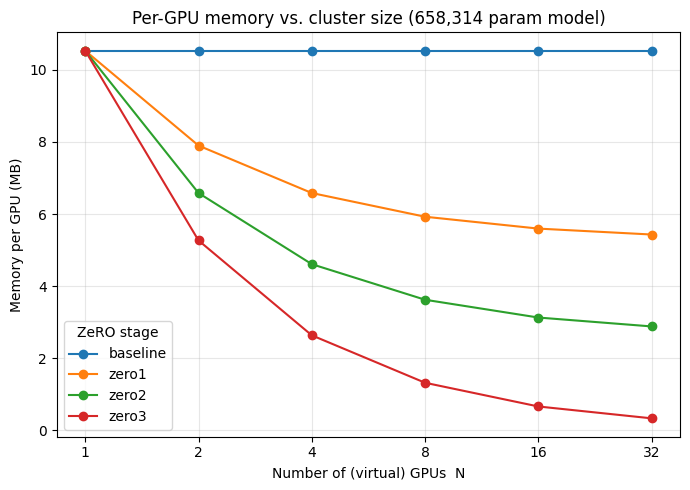

In [6]:
world_sizes = [1, 2, 4, 8, 16, 32]
scaling_rows = []
for N in world_sizes:
    for stage in stages:
        m = TinyMLP(seed=0)
        cluster = ZeROCluster(m, world_size=N, stage=stage)
        rep = cluster.training_step(x, y)
        mem0 = rep.per_gpu_memory[0]["total"]
        scaling_rows.append({"world_size": N, "stage": stage, "mem_MB_per_gpu": mem0 / 1e6})

scaling_df = pd.DataFrame(scaling_rows)

fig, ax = plt.subplots(figsize=(7, 5))
for stage in stages:
    sub = scaling_df[scaling_df.stage == stage].sort_values("world_size")
    ax.plot(sub.world_size, sub.mem_MB_per_gpu, marker="o", label=stage)
ax.set_xscale("log", base=2)
ax.set_xticks(world_sizes)
ax.set_xticklabels(world_sizes)
ax.set_xlabel("Number of (virtual) GPUs  N")
ax.set_ylabel("Memory per GPU (MB)")
ax.set_title(f"Per-GPU memory vs. cluster size ({model.n_params:,} param model)")
ax.legend(title="ZeRO stage")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../assets/memory_vs_world_size.png", dpi=130)
plt.show()

The baseline is a flat line. Adding GPUs never reduces what any one of them
has to store, it only lets you push more data through. The three ZeRO curves
all bend downward as `1/N`, with ZeRO-3 dropping fastest since it shards all
three buffers instead of one or two.

At `N=1` the four stages land on the same point, which is the sanity check
here: sharding across a single device is a no-op, so ZeRO should collapse back
to ordinary training, and it does.

## 5. What it costs: communication per step

Now the other side of the trade, holding `N` fixed at 32.

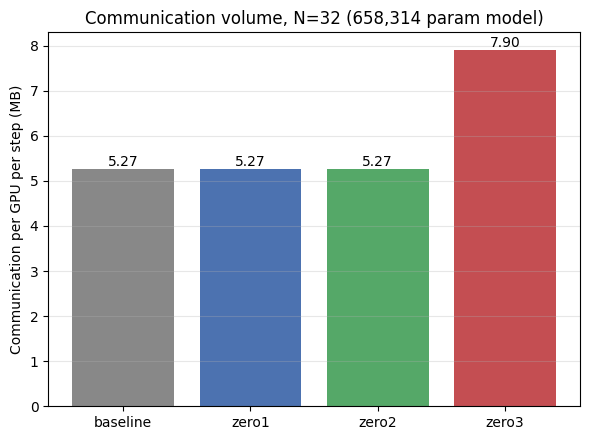

baseline :  5.267 MB/GPU  (1.00x baseline)
zero1    :  5.267 MB/GPU  (1.00x baseline)
zero2    :  5.267 MB/GPU  (1.00x baseline)
zero3    :  7.900 MB/GPU  (1.50x baseline)


In [7]:
comm_rows = [{"stage": s, "comm_MB_per_gpu": reports[s].comm_bytes_per_gpu / 1e6} for s in stages]
comm_df = pd.DataFrame(comm_rows)

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(comm_df.stage, comm_df.comm_MB_per_gpu,
              color=["#888888", "#4C72B0", "#55A868", "#C44E52"])
for b, v in zip(bars, comm_df.comm_MB_per_gpu):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom")
ax.set_ylabel("Communication per GPU per step (MB)")
ax.set_title(f"Communication volume, N=32 ({model.n_params:,} param model)")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../assets/comm_vs_stage.png", dpi=130)
plt.show()

baseline_comm = comm_df.loc[comm_df.stage == "baseline", "comm_MB_per_gpu"].item()
for _, row in comm_df.iterrows():
    print(f"{row.stage:9s}: {row.comm_MB_per_gpu:6.3f} MB/GPU  "
          f"({row.comm_MB_per_gpu / baseline_comm:.2f}x baseline)")

ZeRO-1 and ZeRO-2 come out level with the baseline. The reduce-scatter plus
all-gather pair moves the same total bytes as a single all-reduce, since
that's how an all-reduce is built internally, so the traffic is simply
redistributed across the cluster rather than increased.

ZeRO-3 sits noticeably higher, about 1.5× baseline. It pays for two extra
all-gathers of the full parameter vector, one before the forward pass and one
before the backward pass, which the other stages never need because they keep
a full copy of the weights in memory the whole time.

## 6. Confirming the compute doesn't change

The claim earlier was that ZeRO moves memory and communication around without
touching FLOPs. Timing each stage puts a number on that.

In [8]:
import time

def time_stage(stage, reps=20):
    m = TinyMLP(seed=0)
    cluster = ZeROCluster(m, world_size=WORLD_SIZE, stage=stage)
    cluster.training_step(x, y)  # warm-up
    t0 = time.perf_counter()
    for _ in range(reps):
        cluster.training_step(x, y)
    return (time.perf_counter() - t0) / reps

timings = {stage: time_stage(stage) for stage in stages}
for stage, t in timings.items():
    print(f"{stage:9s}: {t*1000:7.3f} ms / step  (includes simulated comm bookkeeping)")

baseline : 226.908 ms / step  (includes simulated comm bookkeeping)
zero1    :  11.906 ms / step  (includes simulated comm bookkeeping)
zero2    :   4.800 ms / step  (includes simulated comm bookkeeping)
zero3    :   5.218 ms / step  (includes simulated comm bookkeeping)


The baseline comes out much slower than the ZeRO stages, which looks at first
like it contradicts everything above. It doesn't, and the reason is worth
separating out carefully.

The forward and backward passes do identical FLOPs in all four stages. This
simulator calls `model.forward` and `model.backward` exactly once per step, to
represent the compute one GPU performs, and that part never varies.

The Adam step is also compute, though, a handful of element-wise operations
over every parameter, and that part genuinely does shrink. Under the baseline
all 32 simulated GPUs redundantly run a full Adam update across all 658K
parameters. From ZeRO-1 onward each GPU only updates the roughly 1/32 slice it
owns. Removing that redundancy is a real saving, but a small one in practice,
because Adam's element-wise update is far cheaper per parameter than the
matrix multiplies in forward and backward. That's why ZeRO is described as a
memory and communication optimization rather than a compute one.

On real hardware the matmuls dominate wall-clock time completely, so this
optimizer saving is a minor bonus and ZeRO-3's extra traffic is the thing that
actually matters at scale.

## 7. Summary

| | Baseline (DDP) | ZeRO-1 | ZeRO-2 | ZeRO-3 |
|---|---|---|---|---|
| Optimizer state | replicated | **sharded** | sharded | sharded |
| Gradients | replicated | replicated | **sharded** | sharded |
| Parameters | replicated | replicated | replicated | **sharded** |
| Memory / GPU (bytes/param, N=32) | 16 | 8.25 | 4.375 | 0.5 |
| Extra communication vs. baseline | | ~0% | ~0% | ~+50% |
| FLOPs / GPU | same | same | same | same |

The measured results in sections 2 through 5 match this table for a 658K
parameter model on 32 simulated GPUs, and the check in section 3 confirms the
simulator reproduces the real partitioning scheme rather than approximating it.

A few things this deliberately leaves out: mixed-precision training, where the
`K=12` constant from the ZeRO paper comes from keeping fp16 weights and
gradients alongside an fp32 master copy; the bucketing and
communication/compute overlap that production implementations rely on;
ZeRO-Infinity's CPU and NVMe offload; and real network bandwidth and topology.
The README covers each of those in more detail.